## 1. 环境配置与模型加载

In [19]:
import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm.notebook import tqdm

# 设置中文字体（根据系统调整）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 项目路径配置（按需修改）
PROJECT_ROOT = '/data00/chenjiajun/202605/jiangsu_power_predict_gat_informer'
sys.path.insert(0, PROJECT_ROOT)

from api.model.gat_informer_model import GATInformerModel
from api.model.constants import JIANGSU_CITY2_WIND

# 模型文件路径（按需修改）
MODEL_PATH = os.path.join(PROJECT_ROOT, 'local/checkpoints/new_energy_wind_ahead-ahead-by_day-noa-unweighted.pt')

# 初始化并加载模型
model = GATInformerModel(label_type='wind')
model.load(model_name=MODEL_PATH)
model._model.eval()

print(f"模型加载完成: {MODEL_PATH}")
print(f"设备: {model.device}")
print(f"城市列表: {model._city_list}")
print(f"气象列: {model._weather_cols}")
print(f"全局特征列 ({len(model._global_feat_cols) if model._global_feat_cols else 0}): {model._global_feat_cols}")
print(f"节点特征维度: {model._node_feat_dim}")
print(f"序列长度: {model.seq_len}")
print(f"GAT d_model: {model.d_gat}, heads: {model.gat_heads}")
print(f"Informer d_model: {model.d_model}, layers: {model.informer_layers}, heads: {model.informer_heads}")

2026-06-17 17:15:11,523 - gat_informer_model.py[line:447] - INFO: [GAT+Informer] Using device: cuda


2026-06-17 17:15:11,567 - gat_informer_model.py[line:1843] - INFO: [GAT+Informer] Model loaded: /data00/chenjiajun/202605/jiangsu_power_predict_gat_informer/local/checkpoints/new_energy_wind_ahead-ahead-by_day-noa-unweighted.pt


模型加载完成: /data00/chenjiajun/202605/jiangsu_power_predict_gat_informer/local/checkpoints/new_energy_wind_ahead-ahead-by_day-noa-unweighted.pt
设备: cuda
城市列表: ['盐城市', '徐州市', '南通市', '连云港市', '泰州市', '宿迁市']
气象列: ['windspeed_100m', 'windspeed_200m', 'pressure_surface']
全局特征列 (8): ['time_idx', 'data_hour_sin', 'data_hour_cos', 'data_day', 'data_month_sin', 'data_month_cos', 'data_minute_sin', 'data_minute_cos']
节点特征维度: 26
序列长度: 96
GAT d_model: 32, heads: 4
Informer d_model: 64, layers: 2, heads: 4


In [20]:

pdf_weather = pd.read_csv('/data00/chenjiajun/202605/jiangsu_power_predict_gat_informer/jiangsu_weather.csv')
pdf_test = pd.read_csv('/data00/chenjiajun/202605/jiangsu_power_predict_gat_informer/output/pdf_rst_jiangsu.csv')
pdf_test['date_time'] = pd.to_datetime(pdf_test['date_time'])
pdf_weather['date_time'] = pd.to_datetime(pdf_weather['date_time'])

pdf_test = pdf_test.merge(pdf_weather, on='date_time', how='left')
pdf_test = pdf_test.dropna(axis=1, how='any')

pdf_test = pdf_test.sort_values('date_time').reset_index(drop=True)
print(f"测试数据加载完成: {pdf_test.shape[0]} 行")
print(f"测试数据加载完成: {pdf_test.head(10)}")



测试数据加载完成: 1149 行
测试数据加载完成:             date_time            version_x  new_energy_wind_pred  \
0 2026-06-05 00:00:00  2026-06-04 20:00:00           3982.093154   
1 2026-06-05 00:15:00  2026-06-04 20:00:00           3978.448110   
2 2026-06-05 00:30:00  2026-06-04 20:00:00           3970.955005   
3 2026-06-05 00:45:00  2026-06-04 20:00:00           3959.260021   
4 2026-06-05 01:00:00  2026-06-04 20:00:00           3942.960955   
5 2026-06-05 01:15:00  2026-06-04 20:00:00           3921.753552   
6 2026-06-05 01:30:00  2026-06-04 20:00:00           3895.617306   
7 2026-06-05 01:45:00  2026-06-04 20:00:00           3865.008657   
8 2026-06-05 02:00:00  2026-06-04 20:00:00           3831.015140   
9 2026-06-05 02:15:00  2026-06-04 20:00:00           3795.411041   

   new_energy_wind_ahead            version_y  version_diff  \
0                4968.43  2026-06-04 20:00:00           1.0   
1                2582.31  2026-06-04 20:00:00           1.0   
2                2561.38  2026-06-0

## 3. 基线预测（Baseline）

In [22]:
# 对齐测试数据列与模型训练时一致：直接复用 pipeline.py get_feature_list 的列筛选逻辑
feature_cols = []

# 1. 原始气象列（与 pipeline.py 中 main_features 一致）
wind_weather_features = ['windspeed_100m', 'windspeed_200m']
city_list = model._city_list
for feat in wind_weather_features:
    for city in city_list:
        col = f'{feat}_{city}'
        if col in pdf_test.columns:
            feature_cols.append(col)

# 2. feature_list2（时间编码 + diff/mean）
feature_list2 = [
    'data_hour_sin', 'data_hour_cos', 'data_day',
    'data_month_sin', 'data_month_cos',
    'data_minute_sin', 'data_minute_cos',
    'windspeed_100m_盐城_扬州_diff', 'windspeed_100m_南通_扬州_diff',
    'windspeed_100m_盐城_淮安_diff', 'windspeed_100m_连云港_徐州_diff',
    'windspeed_100m_southern_mean', 'windspeed_100m_northern_mean'
]
for col in feature_list2:
    if col in pdf_test.columns:
        feature_cols.append(col)

# # 3. lag 列（与 pipeline.py feature_list3 条件一致）
# for col in pdf_test.columns:
#     if '_lag_' in col and 'windspeed_' in col and '_capa_w_' not in col:
#         feature_cols.append(col)

# 4. 时间索引（如果存在）
if 'time_idx' in pdf_test.columns:
    feature_cols.append('time_idx')

# 5. 保留标签和时间列
for c in ['new_energy_wind_ahead', 'date_time']:
    if c in pdf_test.columns:
        feature_cols.append(c)

pdf_test = pdf_test[feature_cols]
print(f"列对齐后测试数据: {pdf_test.shape[1]} 列")
print(f"保留的列示例: {list(pdf_test.columns)[:10]}...")
def get_baseline_prediction(pdf_data, model):
    """获取基线预测值。"""
    preds = model.predict(feature=pdf_data.copy())
    return preds
# 注意：请确保 pdf_test 已定义后再运行此单元格
baseline_preds = get_baseline_prediction(pdf_test, model)
print(f"基线预测样本数: {len(baseline_preds)}")
print(f"基线预测统计: mean={np.nanmean(baseline_preds):.2f}, std={np.nanstd(baseline_preds):.2f}")

# 如有真实标签，计算基线 MAPE
label_col = 'new_energy_wind_ahead'
if label_col in pdf_test.columns:
    y_true = pdf_test[label_col].values
    valid_mask = np.isfinite(y_true) & np.isfinite(baseline_preds)
    denom = np.maximum(np.abs(y_true[valid_mask]), 1000.0)
    baseline_mape = np.mean(np.abs(baseline_preds[valid_mask] - y_true[valid_mask]) / denom)
    baseline_acc = 1.0 - baseline_mape
    print(f"基线 MAPE: {baseline_mape:.4f}, Accuracy: {baseline_acc:.4f}")
else:
    print("未找到真实标签列，跳过MAPE计算")

列对齐后测试数据: 27 列
保留的列示例: ['windspeed_100m_盐城市', 'windspeed_100m_徐州市', 'windspeed_100m_南通市', 'windspeed_100m_连云港市', 'windspeed_100m_泰州市', 'windspeed_100m_宿迁市', 'windspeed_200m_盐城市', 'windspeed_200m_徐州市', 'windspeed_200m_南通市', 'windspeed_200m_连云港市']...
基线预测样本数: 1149
基线预测统计: mean=5501.67, std=2660.87
基线 MAPE: 0.4892, Accuracy: 0.5108


In [23]:
def compute_permutation_importance(pdf_data, model, feature_cols, n_repeats=3, metric='mape', seed=42):
    """
    计算排列重要性。
    
    Args:
        pdf_data: pd.DataFrame, 测试数据
        model: GATInformerModel 实例
        feature_cols: list, 待分析的特征列名
        n_repeats: int, 重复打乱次数（取平均降低方差）
        metric: str, 'mape' 或 'mse'
        seed: int
    
    Returns:
        dict: {feature_name: importance_score}
    """
    rng = np.random.RandomState(seed)
    label_col = 'new_energy_wind_ahead'
    has_label = label_col in pdf_data.columns
    
    # 基线误差
    baseline_preds = model.predict(feature=pdf_data.copy())
    if has_label:
        y_true = pdf_data[label_col].values
        valid_mask = np.isfinite(y_true) & np.isfinite(baseline_preds)
        y_true_valid = y_true[valid_mask]
        base_preds_valid = baseline_preds[valid_mask]
        if metric == 'mape':
            denom = np.maximum(np.abs(y_true_valid), 1000.0)
            baseline_err = np.mean(np.abs(base_preds_valid - y_true_valid) / denom)
        else:
            baseline_err = np.mean((base_preds_valid - y_true_valid) ** 2)
    else:
        baseline_err = None
    
    results = {}
    print(feature_cols)
    for col in tqdm(feature_cols, desc="Permutation Importance"):
        if col not in pdf_data.columns:
            results[col] = np.nan
            continue
        
        scores = []
        for _ in range(n_repeats):
            pdf_shuffled = pdf_data.copy()
            # 仅对该列随机排列
            shuffled_vals = pdf_shuffled[col].values.copy()
            rng.shuffle(shuffled_vals)
            pdf_shuffled[col] = shuffled_vals
            
            preds_shuffled = model.predict(feature=pdf_shuffled)
            
            if has_label and baseline_err is not None:
                valid_mask = np.isfinite(y_true) & np.isfinite(preds_shuffled)
                yv = y_true[valid_mask]
                pv = preds_shuffled[valid_mask]
                if metric == 'mape':
                    denom = np.maximum(np.abs(yv), 1000.0)
                    err = np.mean(np.abs(pv - yv) / denom)
                else:
                    err = np.mean((pv - yv) ** 2)
                scores.append(err - baseline_err)  # delta error
            else:
                # 无标签时，使用预测值的变化量（标准差）作为代理指标
                valid_mask = np.isfinite(baseline_preds) & np.isfinite(preds_shuffled)
                diff = np.abs(preds_shuffled[valid_mask] - baseline_preds[valid_mask])
                scores.append(np.mean(diff))
        
        results[col] = np.mean(scores)
    
    return results, baseline_err


# 构造待分析的特征列表
# 分类：城市级气象特征 + 全局特征
city_list = model._city_list
weather_cols = model._weather_cols
global_feat_cols = model._global_feat_cols or []

# 城市级气象特征（完整列名）：匹配原始气象列（不再使用 capa_w 加权列）
city_weather_features = []
for city in city_list:
    for wc in weather_cols:
        col = f"{wc}_{city}"
        if col in pdf_test.columns:
            city_weather_features.append(col)

# 合并所有待分析特征
all_feature_cols = city_weather_features + [c for c in global_feat_cols if c in pdf_test.columns]

print(f"待分析特征总数: {len(all_feature_cols)}")
print(f"城市气象特征: {len(city_weather_features)}")
print(f"全局特征: {len([c for c in global_feat_cols if c in pdf_test.columns])}")

待分析特征总数: 19
城市气象特征: 12
全局特征: 7


In [24]:
# 执行排列重要性计算（n_repeats 越大越稳定但越慢）
perm_importance, baseline_err = compute_permutation_importance(
    pdf_test, model, all_feature_cols, n_repeats=3, metric='mape'
)

# 转为DataFrame并排序
perm_df = pd.DataFrame([
    {'feature': k, 'importance': v, 'category': 'city_weather' if any(c in k for c in city_list) else 'global'}
    for k, v in perm_importance.items()
]).sort_values('importance', ascending=False)

print(f"基线误差: {baseline_err:.4f}")
print("\nTop 20 最重要特征（排列重要性）:")
display(perm_df.head(20))

['windspeed_100m_盐城市', 'windspeed_200m_盐城市', 'windspeed_100m_徐州市', 'windspeed_200m_徐州市', 'windspeed_100m_南通市', 'windspeed_200m_南通市', 'windspeed_100m_连云港市', 'windspeed_200m_连云港市', 'windspeed_100m_泰州市', 'windspeed_200m_泰州市', 'windspeed_100m_宿迁市', 'windspeed_200m_宿迁市', 'data_hour_sin', 'data_hour_cos', 'data_day', 'data_month_sin', 'data_month_cos', 'data_minute_sin', 'data_minute_cos']


Permutation Importance:   0%|          | 0/19 [00:00<?, ?it/s]

基线误差: 0.4892

Top 20 最重要特征（排列重要性）:


,feature,importance,category
13,data_hour_cos,0.020283,global
5,windspeed_200m_南通市,0.010408,city_weather
9,windspeed_200m_泰州市,0.005516,city_weather
4,windspeed_100m_南通市,0.005172,city_weather
10,windspeed_100m_宿迁市,0.003984,city_weather
17,data_minute_sin,0.000963,global
16,data_month_cos,0.000000,global
15,data_month_sin,0.000000,global
0,windspeed_100m_盐城市,-0.001413,city_weather
18,data_minute_cos,-0.001620,global


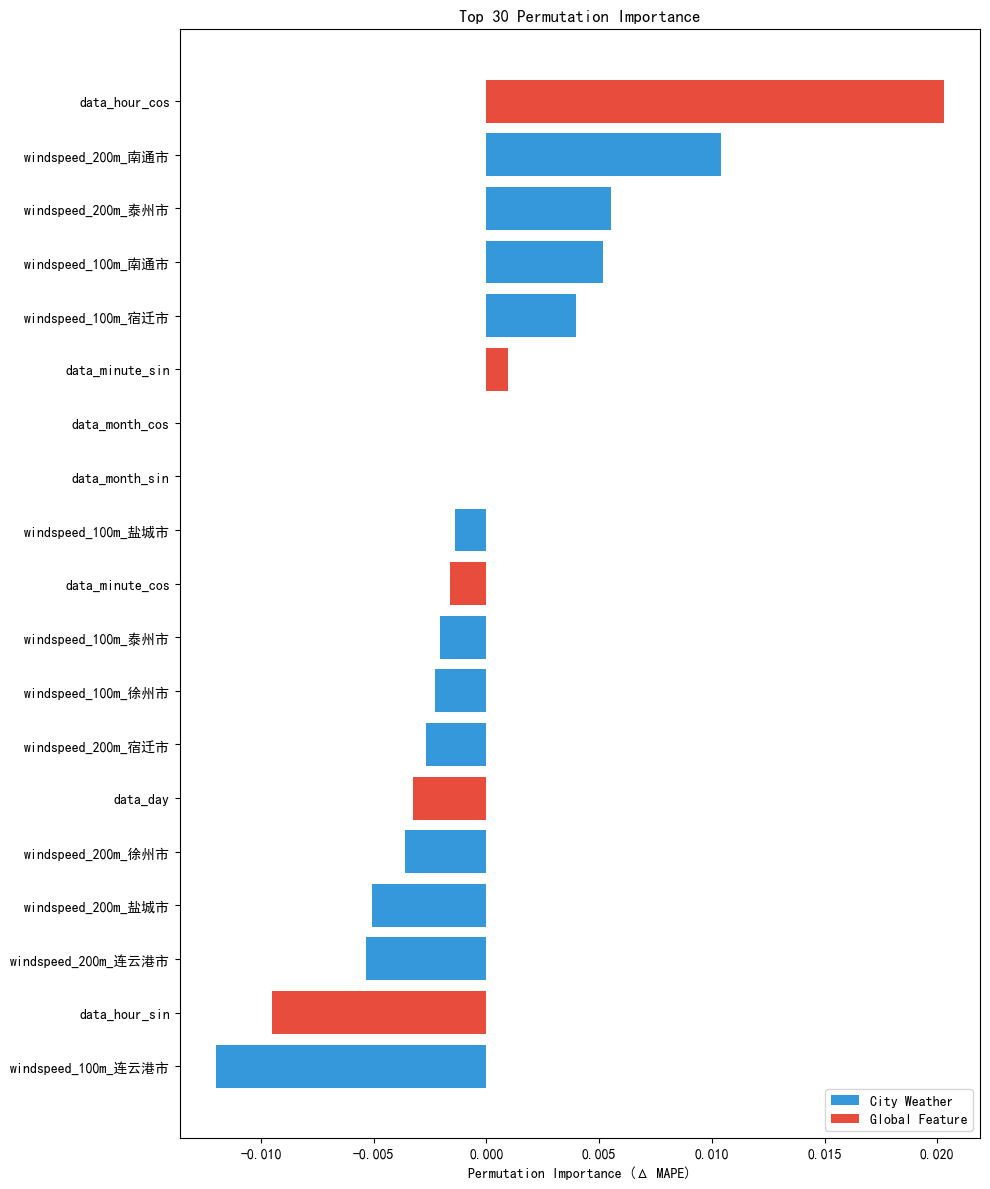

In [25]:
# 可视化：Top 30 排列重要性
fig, ax = plt.subplots(figsize=(10, 12))
top_n = 30
plot_df = perm_df.head(top_n).copy()
colors = plot_df['category'].map({'city_weather': '#3498db', 'global': '#e74c3c'})

ax.barh(range(len(plot_df)), plot_df['importance'].values, color=colors)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Permutation Importance (Δ MAPE)' if baseline_err is not None else 'Permutation Importance (Mean Prediction Change)')
ax.set_title(f'Top {top_n} Permutation Importance')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='City Weather'),
    Patch(facecolor='#e74c3c', label='Global Feature')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

### 4.1 按特征类型聚合的排列重要性

将同类特征（如所有城市的 `windspeed_100m`）聚合，观察哪类气象要素最重要。

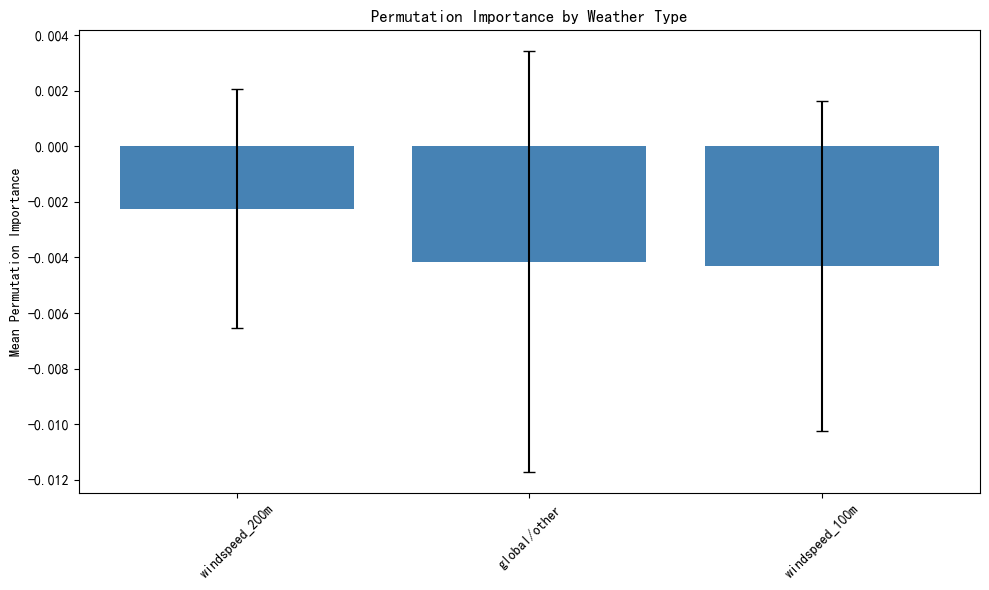

,weather_type,mean_importance,std,count
1,windspeed_200m,-0.002248,0.004310,6
2,global/other,-0.004151,0.007565,7
0,windspeed_100m,-0.004321,0.005939,6


In [14]:
def aggregate_by_weather_type(perm_df, weather_cols):
    """按气象要素类型聚合重要性。"""
    agg = defaultdict(list)
    for _, row in perm_df.iterrows():
        feat = row['feature']
        imp = row['importance']
        matched = False
        # 匹配原始气象列（不再使用 capa_w 加权列）
        for wc in weather_cols:
            if feat.startswith(f"{wc}_"):
                agg[wc].append(imp)
                matched = True
                break
        if not matched:
            agg['global/other'].append(imp)
    
    agg_mean = {k: np.mean(v) for k, v in agg.items()}
    agg_std = {k: np.std(v) for k, v in agg.items()}
    return agg_mean, agg_std

agg_mean, agg_std = aggregate_by_weather_type(perm_df, weather_cols)
agg_df = pd.DataFrame([
    {'weather_type': k, 'mean_importance': v, 'std': agg_std[k], 'count': len([x for x in perm_df['feature'] if any(x.startswith(f"{wc}_") for wc in [k] if k != 'global/other')]) if k != 'global/other' else len([x for x in perm_df['feature'] if not any(x.startswith(f"{wc}_") for wc in weather_cols)])}
    for k, v in agg_mean.items()
]).sort_values('mean_importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(agg_df['weather_type'], agg_df['mean_importance'], yerr=agg_df['std'], capsize=4, color='steelblue')
ax.set_ylabel('Mean Permutation Importance')
ax.set_title('Permutation Importance by Weather Type')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

display(agg_df)

### 4.2 按城市聚合的排列重要性热力图

观察不同城市的气象特征对预测的整体影响。

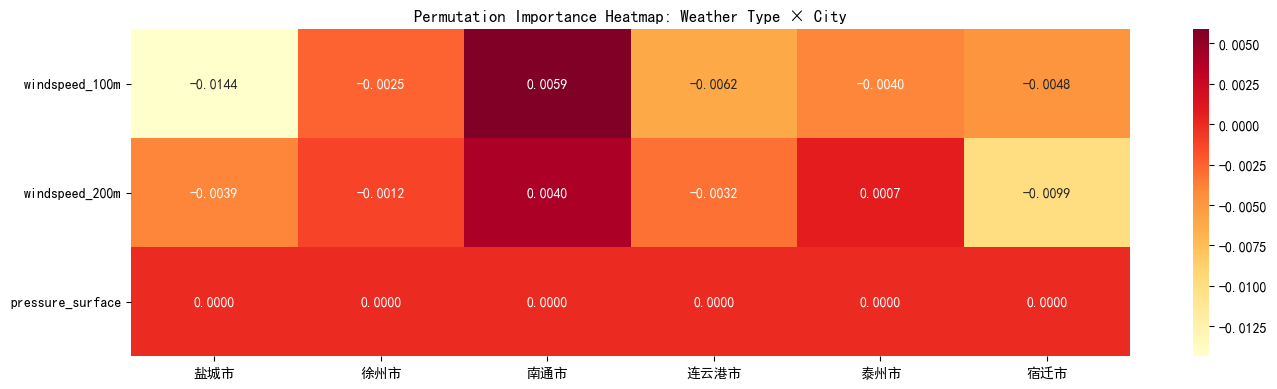

In [15]:
def get_city_importance_matrix(perm_df, weather_cols, city_list):
    """构造 (weather_type x city) 的重要性矩阵。"""
    mat = np.zeros((len(weather_cols), len(city_list)))
    for _, row in perm_df.iterrows():
        feat = row['feature']
        imp = row['importance']
        for i, wc in enumerate(weather_cols):
            for j, city in enumerate(city_list):
                # 使用原始气象列名，不再使用 capa_w 加权列
                if feat == f"{wc}_{city}":
                    mat[i, j] = imp
                    break
    return mat

mat = get_city_importance_matrix(perm_df, weather_cols, city_list)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(mat, xticklabels=city_list, yticklabels=weather_cols, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax)
ax.set_title('Permutation Importance Heatmap: Weather Type × City')
plt.tight_layout()
plt.show()

## 5. Ablation Importance（消融/置零重要性）

**原理**: 将单个特征列的值全部置为 0（或均值），模拟该特征完全缺失的场景，观察预测误差变化。

与 Permutation Importance 的区别：
- Permutation: 破坏特征-标签关联，保留特征分布
- Ablation: 完全移除特征信号，更极端但直观

In [16]:
def compute_ablation_importance(pdf_data, model, feature_cols, fill_value=0.0, metric='mape'):
    """
    计算消融重要性（将特征置零/置均值）。
    
    Args:
        fill_value: 0.0 表示置零；'mean' 表示置为该列均值
    """
    label_col = 'new_energy_wind_ahead'
    has_label = label_col in pdf_data.columns
    
    baseline_preds = model.predict(feature=pdf_data.copy())
    if has_label:
        y_true = pdf_data[label_col].values
        valid_mask = np.isfinite(y_true) & np.isfinite(baseline_preds)
        y_true_valid = y_true[valid_mask]
        base_preds_valid = baseline_preds[valid_mask]
        if metric == 'mape':
            denom = np.maximum(np.abs(y_true_valid), 1000.0)
            baseline_err = np.mean(np.abs(base_preds_valid - y_true_valid) / denom)
        else:
            baseline_err = np.mean((base_preds_valid - y_true_valid) ** 2)
    else:
        baseline_err = None
    
    results = {}
    for col in tqdm(feature_cols, desc="Ablation Importance"):
        if col not in pdf_data.columns:
            results[col] = np.nan
            continue
        
        pdf_ablated = pdf_data.copy()
        if fill_value == 'mean':
            pdf_ablated[col] = pdf_ablated[col].mean()
        else:
            pdf_ablated[col] = fill_value
        
        preds_ablated = model.predict(feature=pdf_ablated)
        
        if has_label and baseline_err is not None:
            valid_mask = np.isfinite(y_true) & np.isfinite(preds_ablated)
            yv = y_true[valid_mask]
            pv = preds_ablated[valid_mask]
            if metric == 'mape':
                denom = np.maximum(np.abs(yv), 1000.0)
                err = np.mean(np.abs(pv - yv) / denom)
            else:
                err = np.mean((pv - yv) ** 2)
            results[col] = err - baseline_err
        else:
            valid_mask = np.isfinite(baseline_preds) & np.isfinite(preds_ablated)
            diff = np.abs(preds_ablated[valid_mask] - baseline_preds[valid_mask])
            results[col] = np.mean(diff)
    
    return results, baseline_err

# 计算消融重要性（置零）
abl_importance, abl_baseline = compute_ablation_importance(
    pdf_test, model, all_feature_cols, fill_value=0.0, metric='mape'
)

abl_df = pd.DataFrame([
    {'feature': k, 'importance': v, 'category': 'city_weather' if any(c in k for c in city_list) else 'global'}
    for k, v in abl_importance.items()
]).sort_values('importance', ascending=False)

print("\nTop 20 最重要特征（消融重要性 - 置零）:")
display(abl_df.head(20))

Ablation Importance:   0%|          | 0/19 [00:00<?, ?it/s]


Top 20 最重要特征（消融重要性 - 置零）:


,feature,importance,category
16,data_month_cos,0.054208,global
14,data_day,0.023638,global
18,data_minute_cos,0.000685,global
15,data_month_sin,0.000000,global
17,data_minute_sin,-0.004248,global
3,windspeed_200m_徐州市,-0.009987,city_weather
2,windspeed_100m_徐州市,-0.012183,city_weather
7,windspeed_200m_连云港市,-0.012510,city_weather
12,data_hour_sin,-0.015854,global
13,data_hour_cos,-0.016304,global


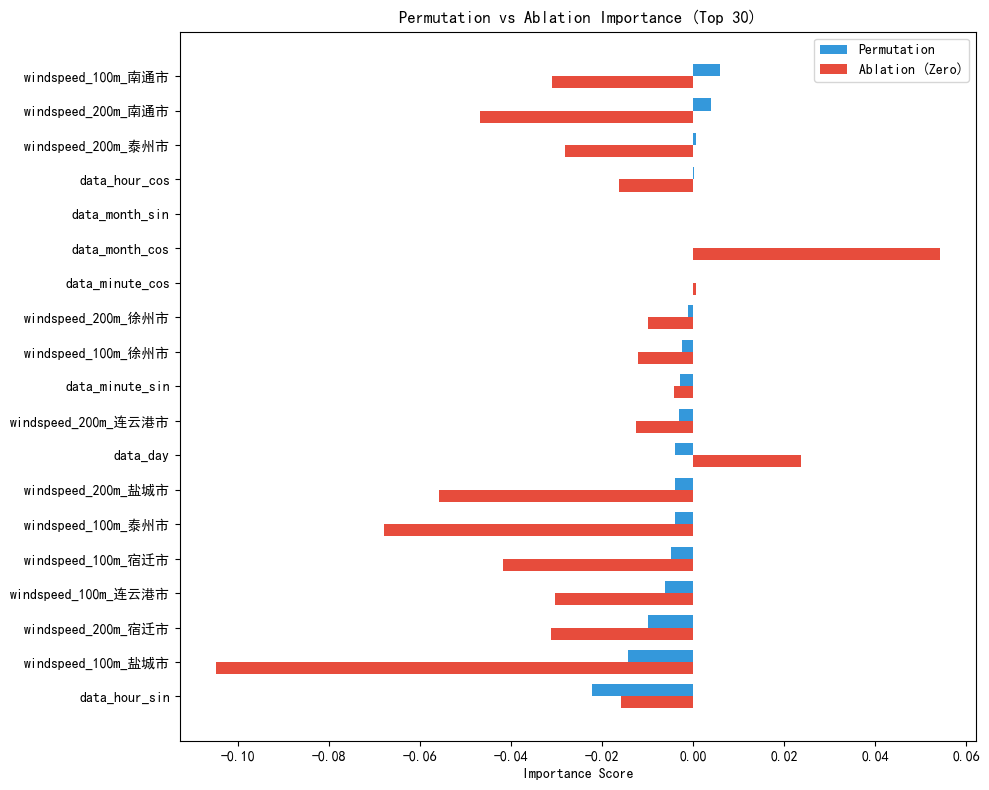

In [17]:
# 对比：Permutation vs Ablation
compare_df = perm_df[['feature', 'importance']].merge(
    abl_df[['feature', 'importance']], on='feature', suffixes=('_perm', '_abl')
)
compare_df = compare_df.sort_values('importance_perm', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = 30
plot_df = compare_df.head(top_n)

y_pos = np.arange(len(plot_df))
width = 0.35
ax.barh(y_pos - width/2, plot_df['importance_perm'], width, label='Permutation', color='#3498db')
ax.barh(y_pos + width/2, plot_df['importance_abl'], width, label='Ablation (Zero)', color='#e74c3c')
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['feature'])
ax.invert_yaxis()
ax.set_xlabel('Importance Score')
ax.set_title(f'Permutation vs Ablation Importance (Top {top_n})')
ax.legend()
plt.tight_layout()
plt.show()

## 6. GAT 图注意力权重可视化

GAT 层的注意力权重反映了城市（节点）之间的空间依赖关系。我们可以通过以下方式分析：
1. **注意力矩阵热力图**: 查看城市间的平均注意力强度
2. **边权重 vs 注意力**: 对比输入边权重与学到的注意力分布

In [18]:
# 提取 GAT 层的注意力权重
# 注意：当前 GATLayer 实现中没有显式保存 alpha，我们需要通过 hook 获取

gat_attention_weights = []

def gat_forward_hook(module, input, output):
    """Hook to capture GAT attention weights."""
    # module 是 GATLayer 实例
    # 我们需要在 forward 中保存 alpha，但当前代码没有保存
    # 这里提供一个思路：修改 GATLayer 的 forward 以返回 alpha
    pass

# 由于当前模型代码未在 forward 中暴露 alpha，我们采用另一种方式：
# 手动复现 GAT 的 forward 逻辑，提取注意力权重

def extract_gat_attention(model_wrapper, x_sample, edge_index, edge_weight):
    """
    手动复现 GATLayer forward，提取注意力矩阵 alpha。
    
    Args:
        model_wrapper: GATInformerModel 实例
        x_sample: torch.Tensor, shape (batch, T, N, D)
        edge_index: torch.Tensor
        edge_weight: torch.Tensor
    
    Returns:
        alpha: np.ndarray, shape (batch, heads, N, N)
    """
    gat_layer = model_wrapper._model.gat
    batch, T, N, D = x_sample.shape
    device = x_sample.device
    
    # 展平时间步
    x_flat = x_sample.reshape(batch * T, N, D)
    
    # 线性变换
    h = gat_layer.W(x_flat).view(batch * T, N, gat_layer.num_heads, gat_layer.head_dim)
    h = h.permute(0, 2, 1, 3)  # (batch*T, heads, N, head_dim)
    
    # 计算注意力分数
    scores_src = (h * gat_layer.att_src).sum(dim=-1, keepdim=True)
    scores_dst = (h * gat_layer.att_dst).sum(dim=-1, keepdim=True)
    scores = scores_src + scores_dst.transpose(-2, -1)
    scores = gat_layer.leaky_relu(scores)
    
    # 获取邻接矩阵
    adj, weight_mat = gat_layer._build_dense_adj(edge_index, edge_weight, N, device)
    
    # 融入边权重
    if weight_mat is not None:
        scores = scores + weight_mat.unsqueeze(0).unsqueeze(0)
    
    # 掩码
    scores = scores.masked_fill(adj.unsqueeze(0).unsqueeze(0) == 0, -1e9)
    alpha = torch.softmax(scores, dim=-1)
    
    # 重塑回 (batch, T, heads, N, N) 并对时间步取平均
    alpha = alpha.view(batch, T, gat_layer.num_heads, N, N)
    alpha_mean = alpha.mean(dim=1)  # (batch, heads, N, N)
    
    return alpha_mean.detach().cpu().numpy()


# 选取一个 batch 的测试样本
# 首先将 pdf_test 转换为时空张量
X_test, y_test, sort_idx = model._tabular_to_spatiotemporal(
    pdf_test, label_col='new_energy_wind_ahead' if 'new_energy_wind_ahead' in pdf_test.columns else None, return_sort_order=True
)

# 标准化
if model._x_scaler is not None:
    x_mean, x_std = model._x_scaler
    X_test_norm = (X_test - x_mean) / x_std
else:
    X_test_norm = X_test

# 转为 tensor
X_tensor = torch.from_numpy(X_test_norm[:1]).to(model.device)  # 取第一个样本做可视化

alpha = extract_gat_attention(model, X_tensor, model.edge_index, model.edge_weight)
print(f"注意力矩阵形状: {alpha.shape}")  # (1, heads, N, N)
print(f"城市数: {len(model._city_list)}")

2026-06-17 15:33:07,672 - gat_informer_model.py[line:763] - INFO: [GAT+Informer] Global features 7 dims: ['data_hour_sin', 'data_hour_cos', 'data_day', 'data_month_sin', 'data_month_cos']...


ValueError: operands could not be broadcast together with shapes (1054,96,6,151) (1,1,1,152) 

In [12]:
# 可视化：各 head 的平均注意力热力图
n_heads = alpha.shape[1]
fig, axes = plt.subplots(1, n_heads, figsize=(5 * n_heads, 4))
if n_heads == 1:
    axes = [axes]

for h_idx in range(n_heads):
    attn_mat = alpha[0, h_idx]  # (N, N)
    sns.heatmap(attn_mat, xticklabels=model._city_list, yticklabels=model._city_list,
                annot=False, cmap='YlOrRd', ax=axes[h_idx], cbar=True,
                vmin=0, vmax=attn_mat.max())
    axes[h_idx].set_title(f'Head {h_idx + 1}')
    axes[h_idx].tick_params(axis='x', rotation=90, labelsize=8)
    axes[h_idx].tick_params(axis='y', rotation=0, labelsize=8)

fig.suptitle('GAT Attention Weights by Head', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 平均所有 heads
alpha_avg = alpha[0].mean(axis=0)  # (N, N)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(alpha_avg, xticklabels=model._city_list, yticklabels=model._city_list,
            annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, cbar=True)
ax.set_title('GAT Attention Weights (Average over Heads)')
plt.tight_layout()
plt.show()

NameError: name 'alpha' is not defined

In [ ]:
# 对比：边输入权重 vs GAT 学到的注意力
# 将 edge_weight 转换为稠密矩阵
N = len(model._city_list)
edge_weight_dense = np.zeros((N, N))
edge_index_np = model.edge_index.cpu().numpy()
edge_weight_np = model.edge_weight.cpu().numpy()
for i in range(edge_index_np.shape[1]):
    src, dst = edge_index_np[0, i], edge_index_np[1, i]
    edge_weight_dense[src, dst] = edge_weight_np[i]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(edge_weight_dense, xticklabels=model._city_list, yticklabels=model._city_list,
            annot=True, fmt='.3f', cmap='Blues', ax=axes[0], cbar=True)
axes[0].set_title('Input Edge Weights')

sns.heatmap(alpha_avg, xticklabels=model._city_list, yticklabels=model._city_list,
            annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1], cbar=True)
axes[1].set_title('GAT Learned Attention (Avg over Heads)')

plt.tight_layout()
plt.show()

## 7. Informer 时序特征重要性（时间步维度）

通过分析 Informer Encoder 最后一层的输出，评估不同时间步对最终预测的贡献。方法：
1. **时间步梯度重要性**: 对输入的每个时间步施加微小扰动，计算输出预测对扰动的敏感度
2. **时间步消融**: 将某个时间步的所有特征置零，观察预测变化

In [ ]:
def compute_temporal_importance(model_wrapper, X_tensor, method='gradient'):
    """
    计算时间步重要性。
    
    Args:
        method: 'gradient' 或 'ablation'
    
    Returns:
        importance: np.ndarray, shape (T,)
    """
    X_tensor = X_tensor.clone().requires_grad_(True)
    model_wrapper._model.eval()
    
    if method == 'gradient':
        # 梯度法：输出对输入的敏感度
        pred = model_wrapper._model(X_tensor, model_wrapper.edge_index, model_wrapper.edge_weight)
        pred_sum = pred.sum()
        pred_sum.backward()
        
        # 梯度绝对值在时间步、节点、特征维度上求和
        grad = X_tensor.grad.abs()  # (batch, T, N, D)
        importance = grad.sum(dim=(0, 2, 3)).cpu().numpy()  # (T,)
        
    elif method == 'ablation':
        with torch.no_grad():
            baseline_pred = model_wrapper._model(X_tensor, model_wrapper.edge_index, model_wrapper.edge_weight)
            T = X_tensor.shape[1]
            importance = np.zeros(T)
            for t in range(T):
                X_abl = X_tensor.clone()
                X_abl[:, t, :, :] = 0
                pred_abl = model_wrapper._model(X_abl, model_wrapper.edge_index, model_wrapper.edge_weight)
                importance[t] = torch.abs(pred_abl - baseline_pred).sum().item()
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # 归一化到 [0, 1]
    importance = importance / (importance.sum() + 1e-10)
    return importance

# 使用第一个 batch 计算
X_tensor_grad = torch.from_numpy(X_test_norm[:4]).to(model.device).requires_grad_(True)
temporal_imp_grad = compute_temporal_importance(model, X_tensor_grad, method='gradient')
temporal_imp_abl = compute_temporal_importance(model, X_tensor_grad, method='ablation')

fig, ax = plt.subplots(figsize=(12, 5))
T = len(temporal_imp_grad)
ax.plot(range(T), temporal_imp_grad, marker='o', label='Gradient-based', color='#3498db')
ax.plot(range(T), temporal_imp_abl, marker='s', label='Ablation-based', color='#e74c3c')
ax.set_xlabel('Time Step Index')
ax.set_ylabel('Normalized Importance')
ax.set_title(f'Temporal Importance (Sequence Length = {T})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"最近时间步 (T-1) 重要性: gradient={temporal_imp_grad[-1]:.4f}, ablation={temporal_imp_abl[-1]:.4f}")
print(f"最远时间步 (0) 重要性: gradient={temporal_imp_grad[0]:.4f}, ablation={temporal_imp_abl[0]:.4f}")

## 8. 综合特征重要性排序与导出

In [ ]:
# 合并两种重要性指标
combined = perm_df[['feature', 'importance']].rename(columns={'importance': 'perm_importance'})
combined = combined.merge(
    abl_df[['feature', 'importance']].rename(columns={'importance': 'abl_importance'}),
    on='feature', how='outer'
)

# 标准化两种指标到同一尺度（Z-score）
for col in ['perm_importance', 'abl_importance']:
    mean = combined[col].mean()
    std = combined[col].std() + 1e-10
    combined[f'{col}_z'] = (combined[col] - mean) / std

# 综合得分 = 平均 Z-score
combined['combined_score'] = combined[['perm_importance_z', 'abl_importance_z']].mean(axis=1)
combined = combined.sort_values('combined_score', ascending=False)

# 添加特征类别（适配原始气象列，不再使用 capa_w 加权列）
def categorize_feature(feat, city_list, weather_cols):
    for city in city_list:
        for wc in weather_cols:
            if feat.startswith(f'{wc}_{city}'):
                return f'weather_{wc}'
    if 'lag' in feat:
        return 'lag_feature'
    if 'diff' in feat or 'mean' in feat:
        return 'derived_feature'
    if any(x in feat for x in ['hour', 'day', 'month', 'minute']):
        return 'time_feature'
    if 'weighted' in feat:
        return 'weighted_aggregate'
    return 'other_global'

combined['category'] = combined['feature'].apply(
    lambda f: categorize_feature(f, city_list, weather_cols)
)

print("综合特征重要性 Top 20:")
display(combined[['feature', 'category', 'perm_importance', 'abl_importance', 'combined_score']].head(20))

In [ ]:
# 按类别聚合
cat_summary = combined.groupby('category').agg({
    'perm_importance': 'mean',
    'abl_importance': 'mean',
    'combined_score': 'mean',
    'feature': 'count'
}).rename(columns={'feature': 'count'}).sort_values('combined_score', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(cat_summary.index, cat_summary['combined_score'], color='teal')
ax.set_ylabel('Mean Combined Score (Z-score)')
ax.set_title('Feature Importance by Category')
ax.tick_params(axis='x', rotation=45)

# 在柱子上标注数量
for bar, count in zip(bars, cat_summary['count']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'n={count}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

display(cat_summary)

In [ ]:
# 导出结果到 CSV
output_path = 'feature_importance_results.csv'
combined.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"结果已导出到: {os.path.abspath(output_path)}")

# 同时导出按城市-气象要素聚合的结果
city_weather_summary = []
for city in city_list:
    for wc in weather_cols:
        col = f'{wc}_capa_w_{city}'
        row = combined[combined['feature'] == col]
        if not row.empty:
            city_weather_summary.append({
                'city': city,
                'weather_type': wc,
                'perm_importance': row['perm_importance'].values[0],
                'abl_importance': row['abl_importance'].values[0],
                'combined_score': row['combined_score'].values[0]
            })

city_weather_df = pd.DataFrame(city_weather_summary)
city_weather_df.to_csv('feature_importance_city_weather.csv', index=False, encoding='utf-8-sig')
print("城市-气象要素聚合结果已导出到: feature_importance_city_weather.csv")

## 10. 滚动回测 Fold 1 实际功率 vs 预测功率对比

诊断 Fold 1（samples≈18676:23768）出现负准确率（Accuracy≈-0.46）的原因，
通过时间序列对比图观察系统性偏差和异常时段。

滚动回测数据加载完成: 4512 条记录
时间范围: 2026-03-26 21:30:00 ~ 2026-06-02 23:00:00
   fold           timestamp       actual    predicted       error
0     1 2026-03-26 21:30:00  5118.979980  4333.263672 -785.716309
1     1 2026-03-26 21:45:00  5148.200195  4206.555176 -941.645020
2     1 2026-03-26 22:00:00  5163.870117  4319.185547 -844.684570
3     1 2026-03-26 22:15:00  5163.649902  4644.787109 -518.862793
4     1 2026-03-26 22:30:00  5150.640137  4518.680664 -631.959473
Fold 1 记录数: 1504
Fold 1 时间范围: 2026-05-11 23:45:00 ~ 2026-06-02 23:00:00
Fold 1 Accuracy=0.7088, MAE=1382.7, Bias=-250.5


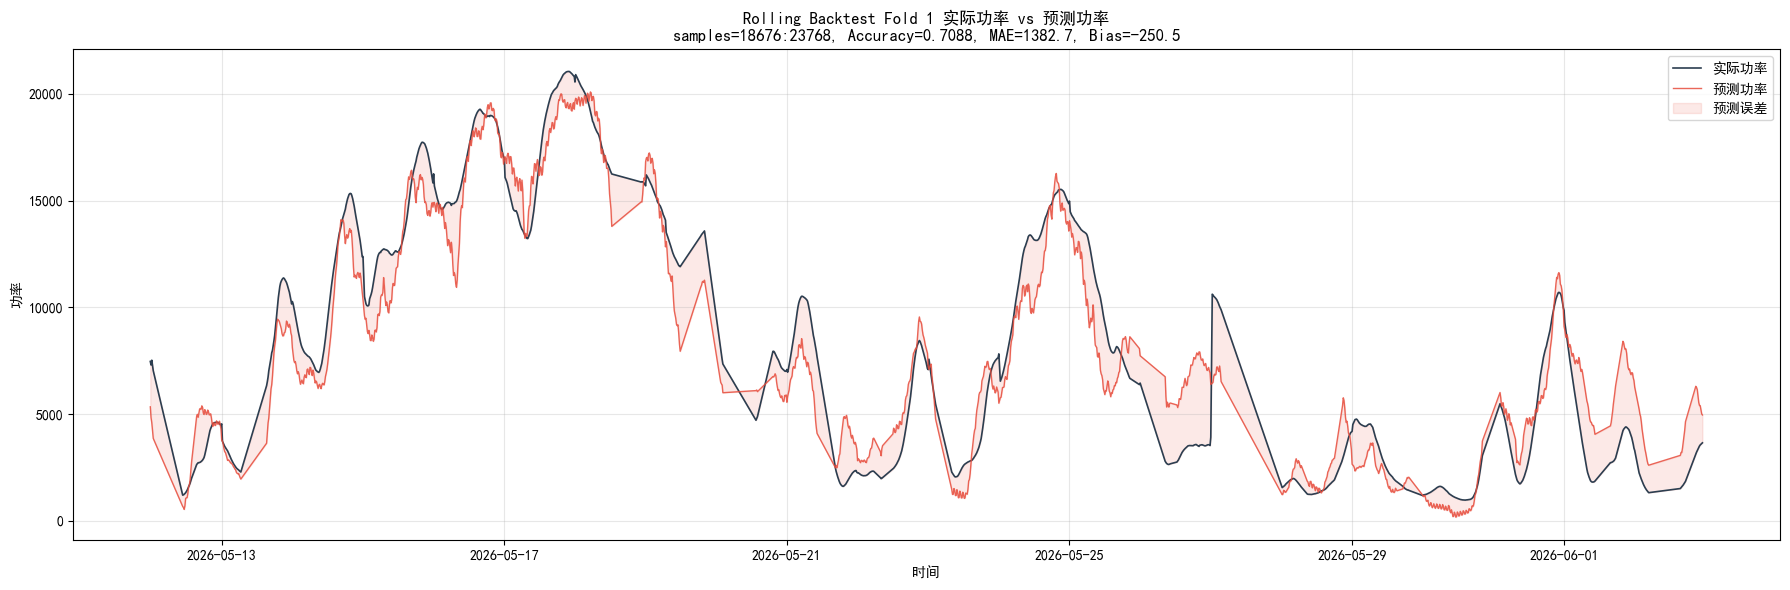

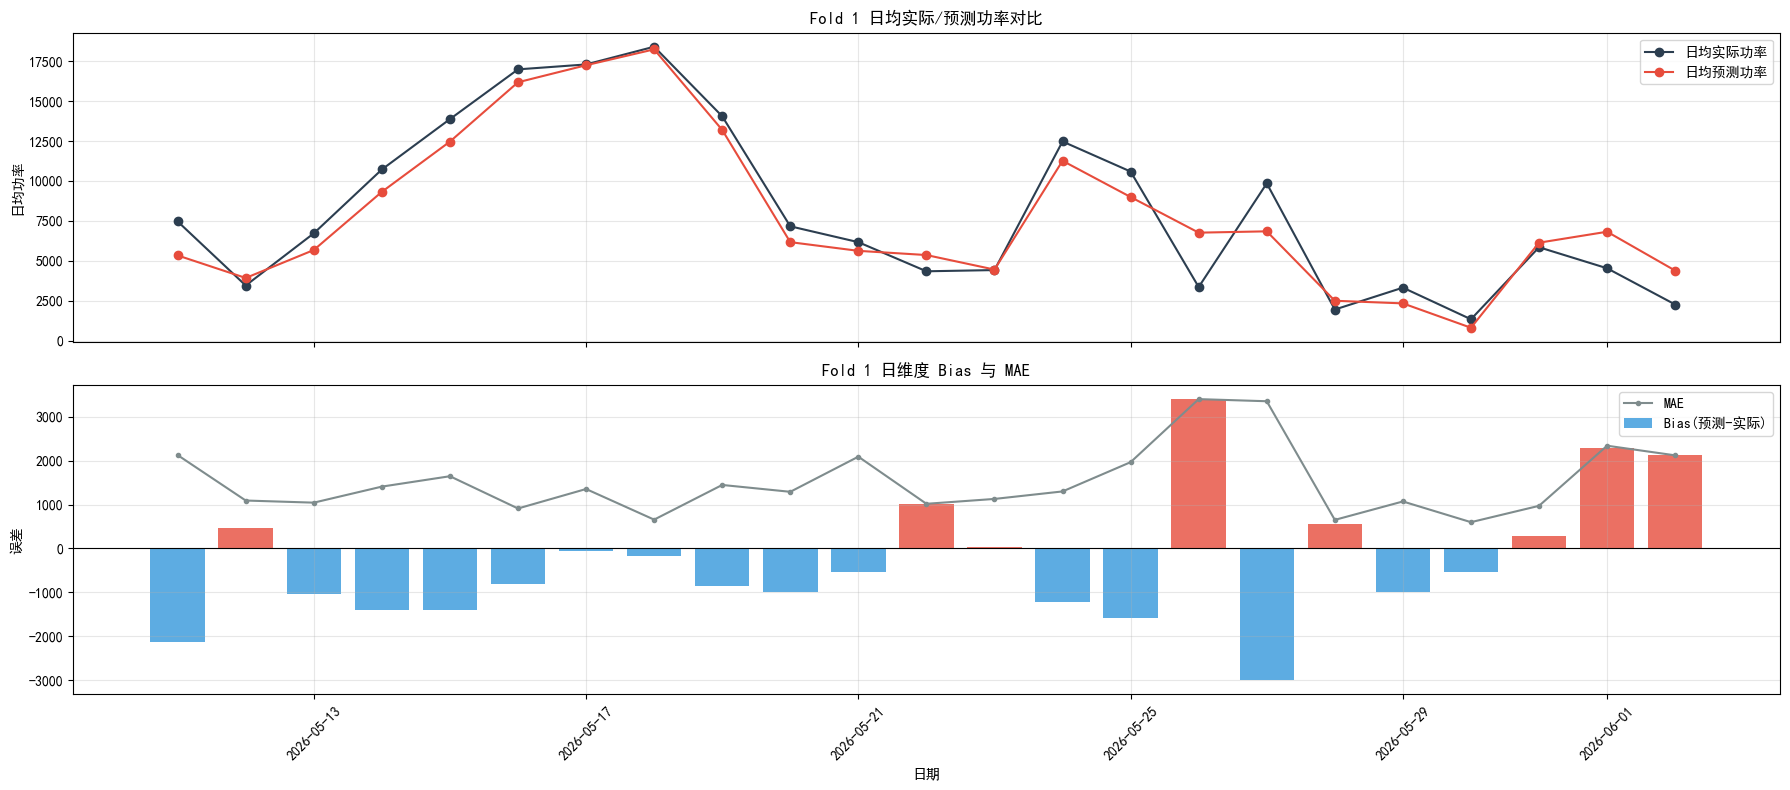

,date,actual_mean,predicted_mean,mae,bias,actual_max,predicted_max
15,2026-05-26,3356.846067,6760.034073,3403.188006,3403.188006,6447.870117,7909.871094
16,2026-05-27,9844.372907,6843.261963,3354.934675,-3001.110944,10613.099609,7247.854004
21,2026-06-01,4531.104866,6817.898918,2341.333083,2286.794052,9853.830078,9100.773438
0,2026-05-11,7462.279785,5334.767578,2127.512207,-2127.512207,7462.279785,5334.767578
22,2026-06-02,2263.341175,4385.207682,2121.866507,2121.866507,3646.780273,6296.873047
10,2026-05-21,6165.596130,5622.491716,2091.649139,-543.104414,10516.530273,8532.082031
14,2026-05-25,10584.259004,8990.628075,1966.725574,-1593.630929,14975.019531,14059.556641
4,2026-05-15,13865.812726,12459.264124,1646.152837,-1406.548602,17734.599609,16422.320312
8,2026-05-19,14043.910048,13189.083306,1447.250859,-854.826742,16203.299805,17234.830078
3,2026-05-14,10714.311457,9315.239736,1409.563522,-1399.071721,15337.040039,14105.187500


In [26]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 设置中文字体（根据系统调整）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
PROJECT_ROOT = '/data00/chenjiajun/202605/jiangsu_power_predict_gat_informer'
sys.path.insert(0, PROJECT_ROOT)

csv_path = os.path.join(PROJECT_ROOT, 'local/checkpoints/visualizations/rolling_backtest_predictions.csv')

if os.path.exists(csv_path):
    pdf_rb = pd.read_csv(csv_path, parse_dates=['timestamp'])
    print(f"滚动回测数据加载完成: {len(pdf_rb)} 条记录")
    print(f"时间范围: {pdf_rb['timestamp'].min()} ~ {pdf_rb['timestamp'].max()}")
    print(pdf_rb.head())
else:
    print(f"回测数据文件不存在: {csv_path}")
    print("提示：需要先运行训练流程中的 rolling_backtest()，让脚本保存预测结果。")

# Fold 1: samples=18676:23768 对应的目标时间段
if 'pdf_rb' in globals() and not pdf_rb.empty:
    fold1 = pdf_rb[pdf_rb['fold'] == 3].copy()
    fold1 = fold1.sort_values('timestamp').reset_index(drop=True)
    fold1['abs_error'] = (fold1['predicted'] - fold1['actual']).abs()

    denom = np.maximum(fold1['actual'].abs(), 1000.0)
    fold1_mape = (fold1['abs_error'] / denom).mean()
    fold1_acc = 1.0 - fold1_mape
    fold1_mae = fold1['abs_error'].mean()
    fold1_bias = (fold1['predicted'] - fold1['actual']).mean()

    print(f"Fold 1 记录数: {len(fold1)}")
    print(f"Fold 1 时间范围: {fold1['timestamp'].min()} ~ {fold1['timestamp'].max()}")
    print(f"Fold 1 Accuracy={fold1_acc:.4f}, MAE={fold1_mae:.1f}, Bias={fold1_bias:.1f}")

    fig, ax = plt.subplots(figsize=(18, 6))
    ax.plot(fold1['timestamp'], fold1['actual'], label='实际功率', color='#2c3e50', linewidth=1.2)
    ax.plot(fold1['timestamp'], fold1['predicted'], label='预测功率', color='#e74c3c', linewidth=1.0, alpha=0.85)
    ax.fill_between(
        fold1['timestamp'],
        fold1['actual'],
        fold1['predicted'],
        color='#e74c3c',
        alpha=0.12,
        label='预测误差'
    )
    ax.set_title(
        f"Rolling Backtest Fold 1 实际功率 vs 预测功率\n"
        f"samples=18676:23768, Accuracy={fold1_acc:.4f}, MAE={fold1_mae:.1f}, Bias={fold1_bias:.1f}"
    )
    ax.set_xlabel('时间')
    ax.set_ylabel('功率')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("未加载到滚动回测数据，无法绘图。")



# 可选：按天聚合，方便观察 Fold 1 的系统性高估/低估发生在哪些日期
if 'fold1' in globals() and not fold1.empty:
    fold1['error'] = fold1['predicted'] - fold1['actual']
    fold1['abs_error'] = fold1['error'].abs()
    daily = (
        fold1.assign(date=fold1['timestamp'].dt.date)
        .groupby('date')
        .agg(
            actual_mean=('actual', 'mean'),
            predicted_mean=('predicted', 'mean'),
            mae=('abs_error', 'mean'),
            bias=('error', 'mean'),
            actual_max=('actual', 'max'),
            predicted_max=('predicted', 'max'),
        )
        .reset_index()
    )

    fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
    axes[0].plot(daily['date'], daily['actual_mean'], marker='o', label='日均实际功率', color='#2c3e50')
    axes[0].plot(daily['date'], daily['predicted_mean'], marker='o', label='日均预测功率', color='#e74c3c')
    axes[0].set_ylabel('日均功率')
    axes[0].set_title('Fold 1 日均实际/预测功率对比')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    colors = np.where(daily['bias'] >= 0, '#e74c3c', '#3498db')
    axes[1].bar(daily['date'], daily['bias'], color=colors, alpha=0.8, label='Bias(预测-实际)')
    axes[1].plot(daily['date'], daily['mae'], marker='.', color='#7f8c8d', label='MAE')
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_xlabel('日期')
    axes[1].set_ylabel('误差')
    axes[1].set_title('Fold 1 日维度 Bias 与 MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    display(daily.sort_values('mae', ascending=False).head(10))
else:
    print("未生成 fold1 数据，跳过日维度分析。")


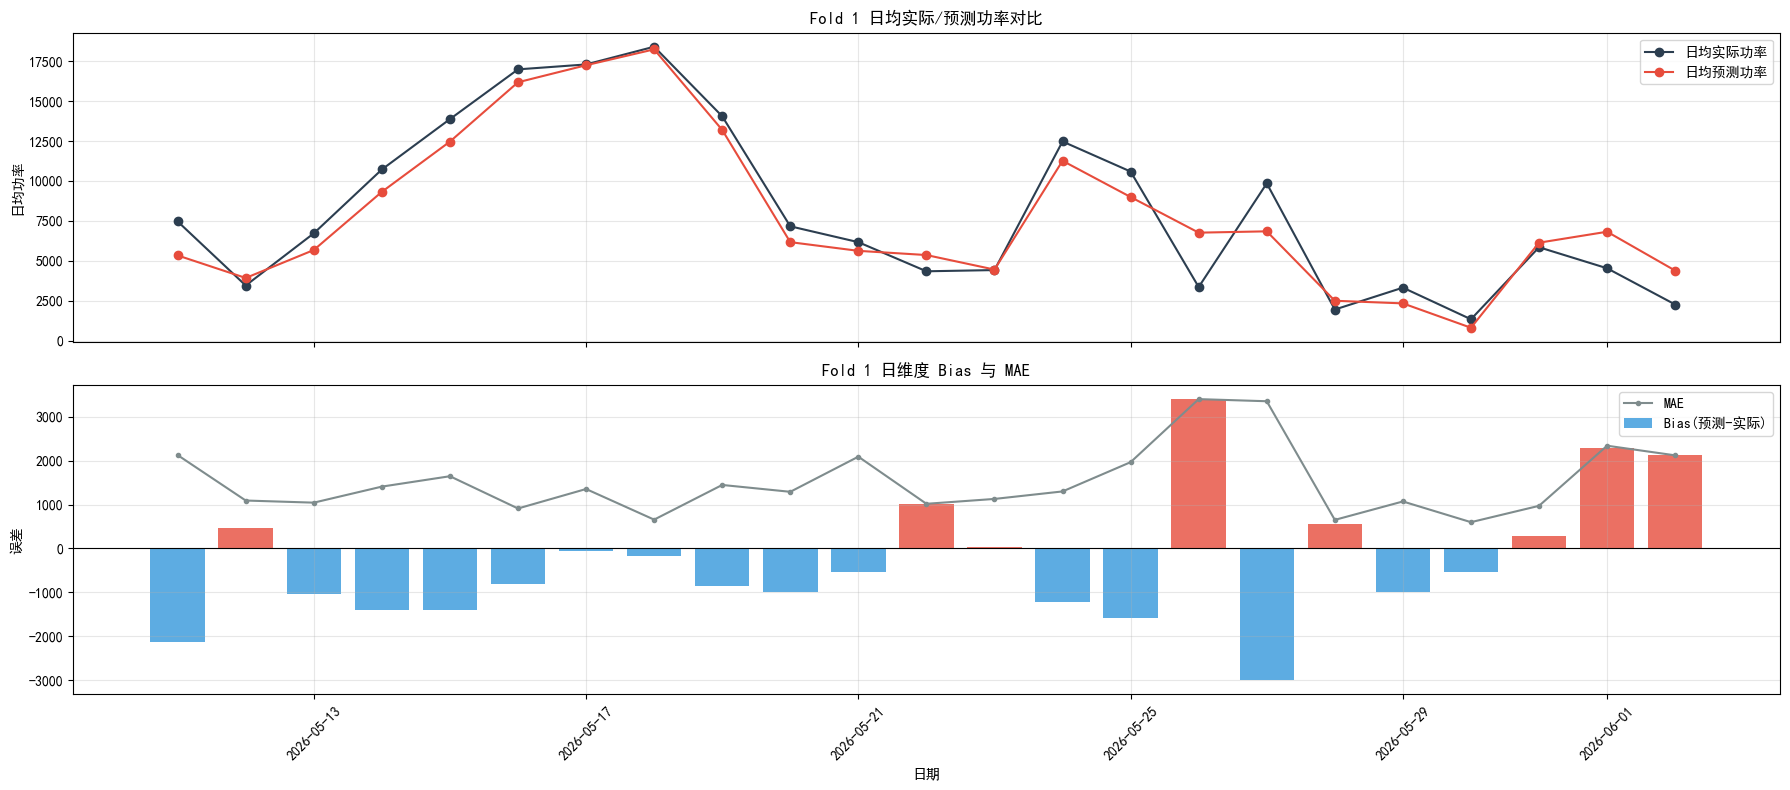

,date,actual_mean,predicted_mean,mae,bias,actual_max,predicted_max
15,2026-05-26,3356.846067,6760.034073,3403.188006,3403.188006,6447.870117,7909.871094
16,2026-05-27,9844.372907,6843.261963,3354.934675,-3001.110944,10613.099609,7247.854004
21,2026-06-01,4531.104866,6817.898918,2341.333083,2286.794052,9853.830078,9100.773438
0,2026-05-11,7462.279785,5334.767578,2127.512207,-2127.512207,7462.279785,5334.767578
22,2026-06-02,2263.341175,4385.207682,2121.866507,2121.866507,3646.780273,6296.873047
10,2026-05-21,6165.596130,5622.491716,2091.649139,-543.104414,10516.530273,8532.082031
14,2026-05-25,10584.259004,8990.628075,1966.725574,-1593.630929,14975.019531,14059.556641
4,2026-05-15,13865.812726,12459.264124,1646.152837,-1406.548602,17734.599609,16422.320312
8,2026-05-19,14043.910048,13189.083306,1447.250859,-854.826742,16203.299805,17234.830078
3,2026-05-14,10714.311457,9315.239736,1409.563522,-1399.071721,15337.040039,14105.187500


In [27]:
# 可选：按天聚合，方便观察 Fold 1 的系统性高估/低估发生在哪些日期
if 'fold1' in globals() and not fold1.empty:
    daily = (
        fold1.assign(date=fold1['timestamp'].dt.date)
        .groupby('date')
        .agg(
            actual_mean=('actual', 'mean'),
            predicted_mean=('predicted', 'mean'),
            mae=('abs_error', 'mean'),
            bias=('error', 'mean'),
            actual_max=('actual', 'max'),
            predicted_max=('predicted', 'max'),
        )
        .reset_index()
    )

    fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
    axes[0].plot(daily['date'], daily['actual_mean'], marker='o', label='日均实际功率', color='#2c3e50')
    axes[0].plot(daily['date'], daily['predicted_mean'], marker='o', label='日均预测功率', color='#e74c3c')
    axes[0].set_ylabel('日均功率')
    axes[0].set_title('Fold 1 日均实际/预测功率对比')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    colors = np.where(daily['bias'] >= 0, '#e74c3c', '#3498db')
    axes[1].bar(daily['date'], daily['bias'], color=colors, alpha=0.8, label='Bias(预测-实际)')
    axes[1].plot(daily['date'], daily['mae'], marker='.', color='#7f8c8d', label='MAE')
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_xlabel('日期')
    axes[1].set_ylabel('误差')
    axes[1].set_title('Fold 1 日维度 Bias 与 MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    display(daily.sort_values('mae', ascending=False).head(10))
else:
    print("未生成 fold1 数据，跳过日维度分析。")


Fold 3 记录数: 1504
Fold 3 时间范围: 2026-05-11 23:45:00 ~ 2026-06-02 23:00:00
Fold 3 Accuracy=0.7088, MAE=1382.7, Bias=-250.5


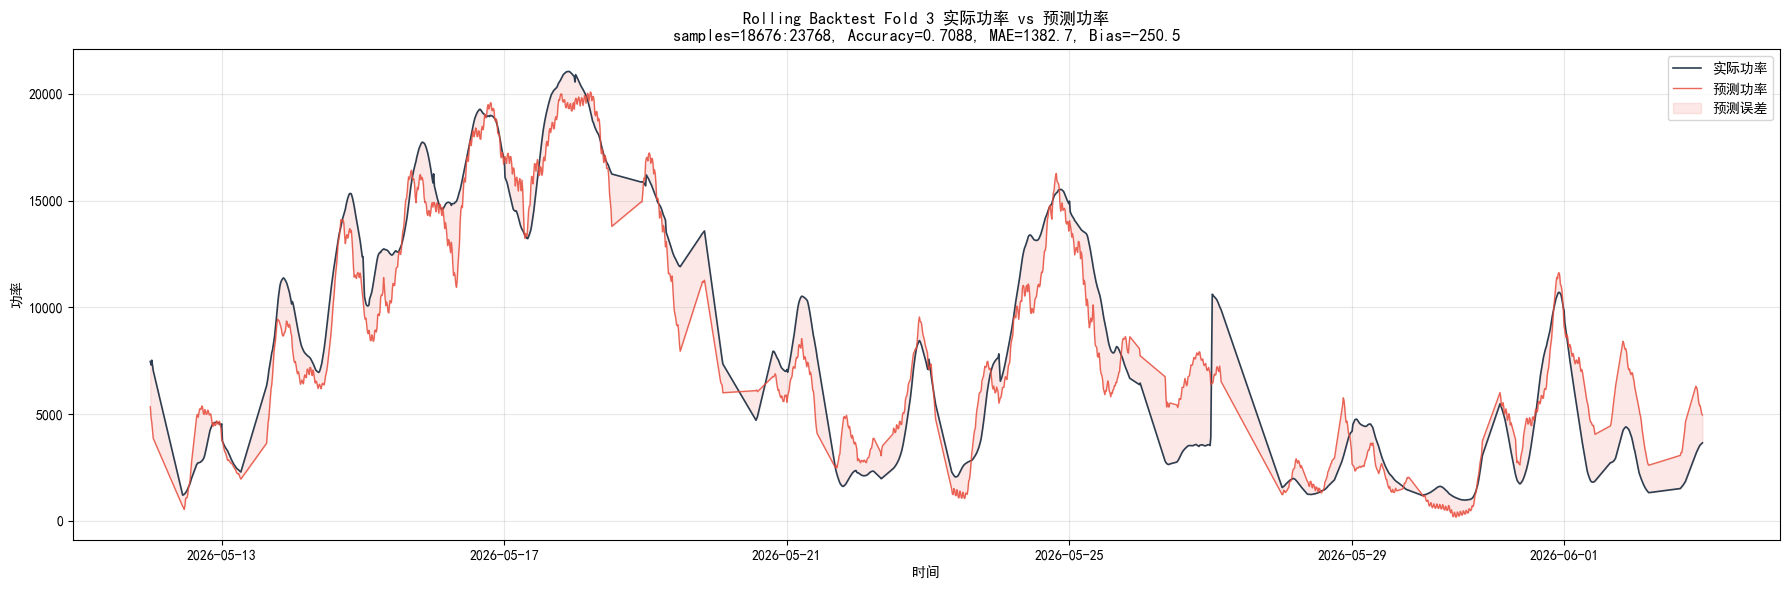

In [28]:
# Fold 1: samples=18676:23768 对应的目标时间段
num = 3
if 'pdf_rb' in globals() and not pdf_rb.empty:
    fold1 = pdf_rb[pdf_rb['fold'] == num].copy()
    fold1 = fold1.sort_values('timestamp').reset_index(drop=True)
    fold1['abs_error'] = (fold1['predicted'] - fold1['actual']).abs()

    denom = np.maximum(fold1['actual'].abs(), 1000.0)
    fold1_mape = (fold1['abs_error'] / denom).mean()
    fold1_acc = 1.0 - fold1_mape
    fold1_mae = fold1['abs_error'].mean()
    fold1_bias = (fold1['predicted'] - fold1['actual']).mean()

    print(f"Fold {num} 记录数: {len(fold1)}")
    print(f"Fold {num} 时间范围: {fold1['timestamp'].min()} ~ {fold1['timestamp'].max()}")
    print(f"Fold {num} Accuracy={fold1_acc:.4f}, MAE={fold1_mae:.1f}, Bias={fold1_bias:.1f}")

    fig, ax = plt.subplots(figsize=(18, 6))
    ax.plot(fold1['timestamp'], fold1['actual'], label='实际功率', color='#2c3e50', linewidth=1.2)
    ax.plot(fold1['timestamp'], fold1['predicted'], label='预测功率', color='#e74c3c', linewidth=1.0, alpha=0.85)
    ax.fill_between(
        fold1['timestamp'],
        fold1['actual'],
        fold1['predicted'],
        color='#e74c3c',
        alpha=0.12,
        label='预测误差'
    )
    ax.set_title(
        f"Rolling Backtest Fold {num} 实际功率 vs 预测功率\n"
        f"samples=18676:23768, Accuracy={fold1_acc:.4f}, MAE={fold1_mae:.1f}, Bias={fold1_bias:.1f}"
    )
    ax.set_xlabel('时间')
    ax.set_ylabel('功率')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("未加载到滚动回测数据，无法绘图。")
